<a href="https://colab.research.google.com/github/sheikhmdsamiul/Question-Pair-Similarity-Classification/blob/main/notebooks/eda_processing_featureeng_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [2]:
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("/content/train.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [ ]:
df.shape

(404351, 6)

In [ ]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [4]:
# Droping rows where either question1 or question2 is null
df = df.dropna(subset=['question1', 'question2'])

In [ ]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [ ]:
df.shape

(404348, 6)

<Axes: xlabel='is_duplicate'>

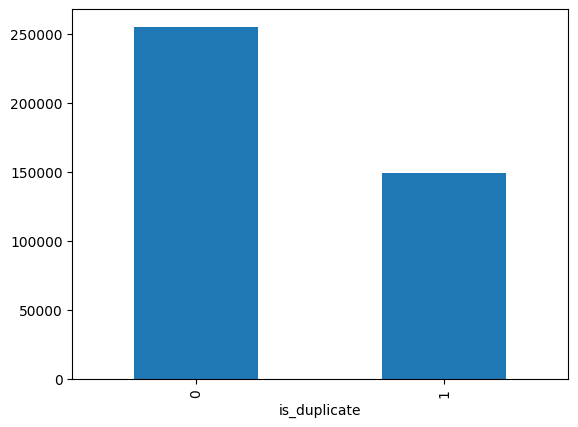

In [ ]:
df['is_duplicate'].value_counts().plot(kind='bar')

In [ ]:
# Percentage of duplicate vs not duplicate
df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100

,count
is_duplicate,
0,63.074876
1,36.925124


Found a mild imbalance of data.

In [ ]:
# Combining all question ids to analyze distribution of questions
all_qids = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())

In [ ]:
print('Total number of questions in the training data:', np.unique(all_qids).shape[0])

Total number of questions in the training data: 789795


In [ ]:
print('Number of questions that appear multiple times: {}'.format(np.sum(all_qids.value_counts() > 1)))

Number of questions that appear multiple times: 13698


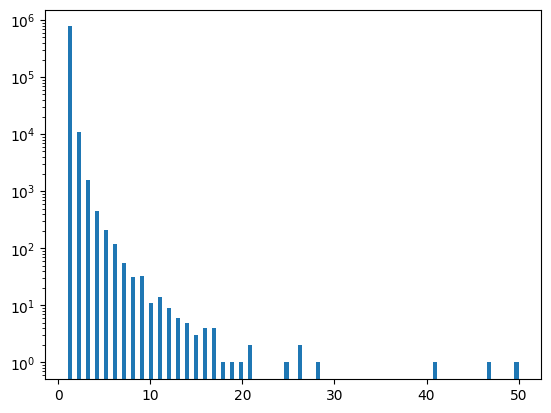

In [ ]:
# Questions occurance histogram
plt.hist(all_qids.value_counts().values,bins=100)
plt.yscale('log')
plt.show()

In [5]:
# Adding question length and word counts
def analyze_text_length(df):
    """Analyze the length of questions"""
    df['q1_length'] = df['question1'].str.len()
    df['q2_length'] = df['question2'].str.len()
    df['q1_word_count'] = df['question1'].str.split().str.len()
    df['q2_word_count'] = df['question2'].str.split().str.len()

    return df

train_df = analyze_text_length(df)

/tmp/ipython-input-4244071247.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([train_df[train_df['is_duplicate']==0]['q1_length'],
/tmp/ipython-input-4244071247.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([train_df[train_df['is_duplicate']==0]['q2_length'],


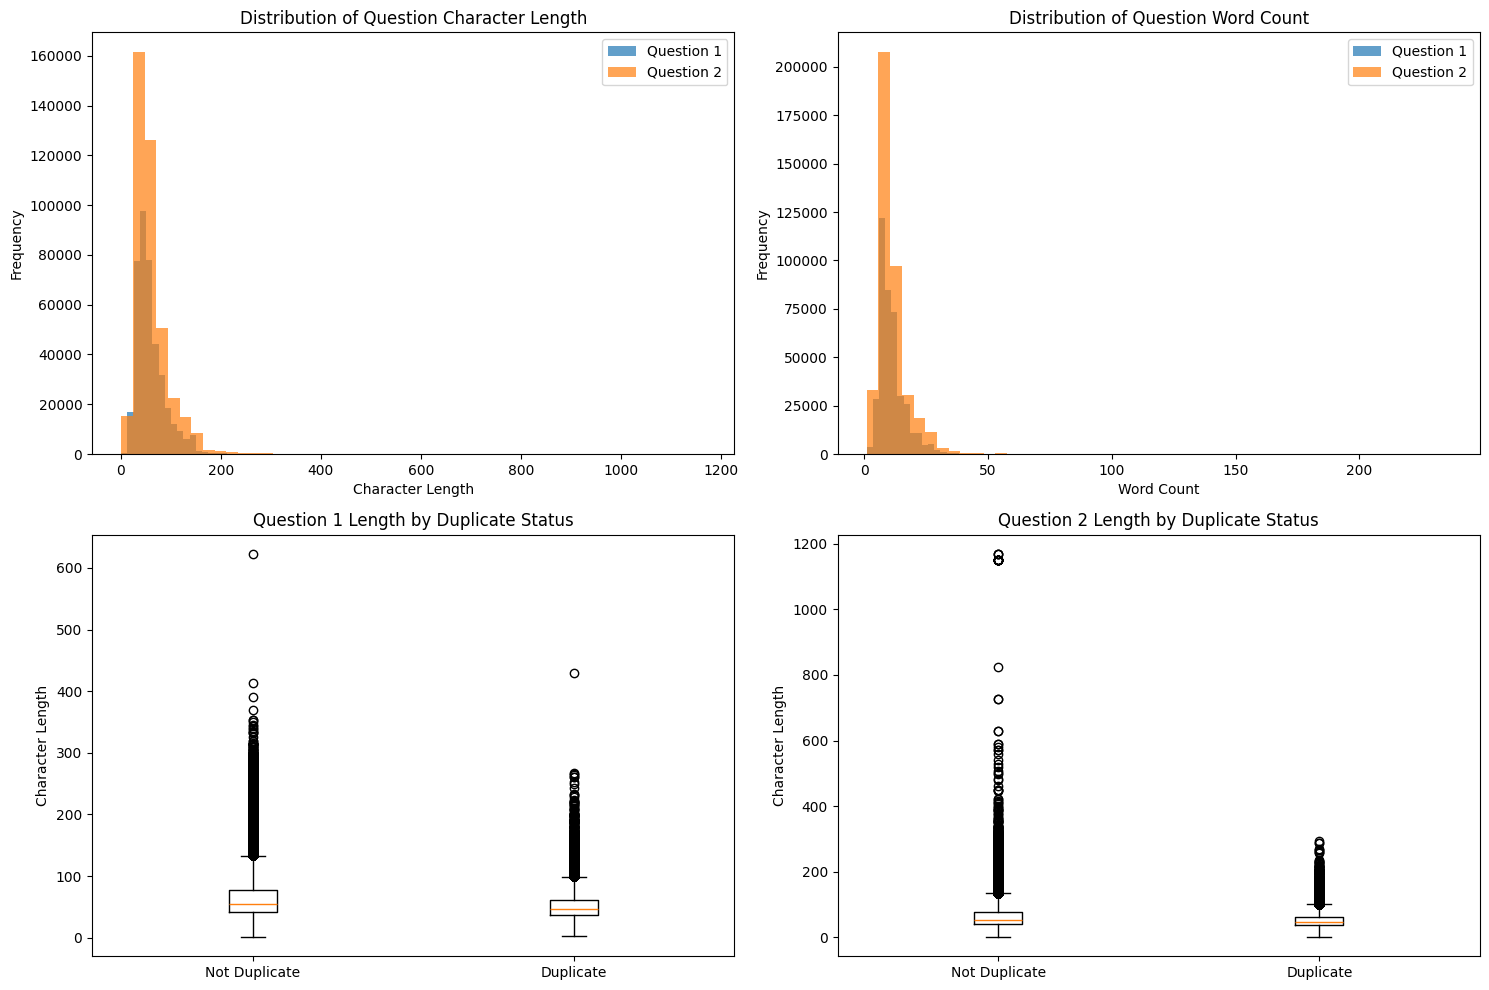

In [ ]:
# Plot text length distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Character length
axes[0, 0].hist(train_df['q1_length'], bins=50, alpha=0.7, label='Question 1')
axes[0, 0].hist(train_df['q2_length'], bins=50, alpha=0.7, label='Question 2')
axes[0, 0].set_title('Distribution of Question Character Length')
axes[0, 0].set_xlabel('Character Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Word count
axes[0, 1].hist(train_df['q1_word_count'], bins=50, alpha=0.7, label='Question 1')
axes[0, 1].hist(train_df['q2_word_count'], bins=50, alpha=0.7, label='Question 2')
axes[0, 1].set_title('Distribution of Question Word Count')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Length by target variable
axes[1, 0].boxplot([train_df[train_df['is_duplicate']==0]['q1_length'],
                   train_df[train_df['is_duplicate']==1]['q1_length']],
                  labels=['Not Duplicate', 'Duplicate'])
axes[1, 0].set_title('Question 1 Length by Duplicate Status')
axes[1, 0].set_ylabel('Character Length')

axes[1, 1].boxplot([train_df[train_df['is_duplicate']==0]['q2_length'],
                   train_df[train_df['is_duplicate']==1]['q2_length']],
                  labels=['Not Duplicate', 'Duplicate'])
axes[1, 1].set_title('Question 2 Length by Duplicate Status')
axes[1, 1].set_ylabel('Character Length')

plt.tight_layout()
plt.show()

From the visuals we can see that duplicates have quite similar lengths and non duplicates have more variation.

In [ ]:
from wordcloud import WordCloud

# Word Cloud for duplicate and non-duplicate questions
def generate_wordcloud(text, title):
    """Generate word cloud from text"""
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

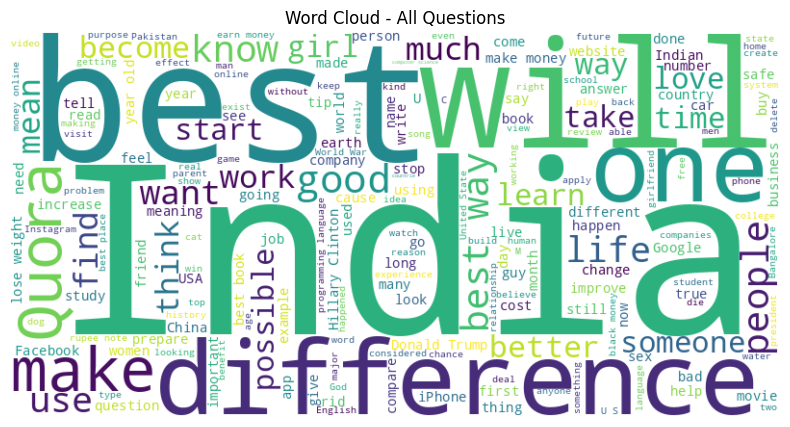

In [ ]:
# Combine all questions for word cloud
all_questions = ' '.join(train_df['question1'].astype(str) + ' ' + train_df['question2'].astype(str))
generate_wordcloud(all_questions, 'Word Cloud - All Questions')

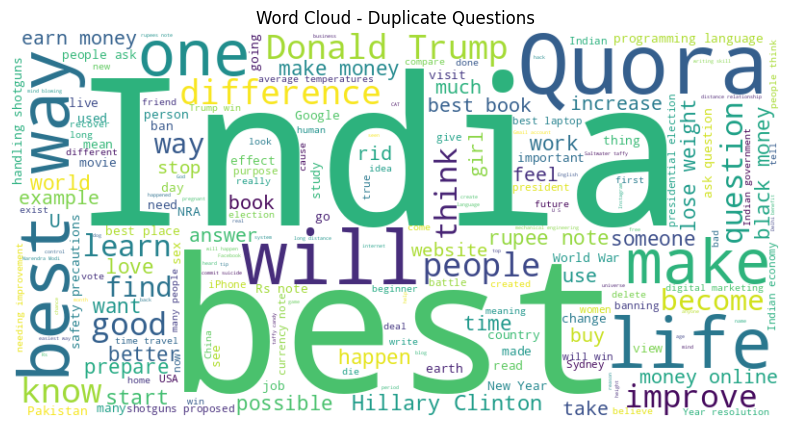

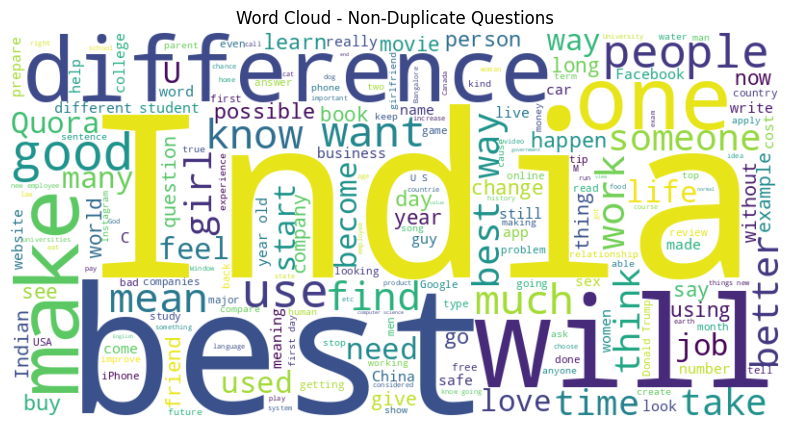

In [ ]:
# Separate duplicate and non-duplicate questions
duplicate_questions = ' '.join(train_df[train_df['is_duplicate']==1]['question1'].astype(str) + ' ' +
                              train_df[train_df['is_duplicate']==1]['question2'].astype(str))
non_duplicate_questions = ' '.join(train_df[train_df['is_duplicate']==0]['question1'].astype(str) + ' ' +
                                  train_df[train_df['is_duplicate']==0]['question2'].astype(str))

generate_wordcloud(duplicate_questions, 'Word Cloud - Duplicate Questions')
generate_wordcloud(non_duplicate_questions, 'Word Cloud - Non-Duplicate Questions')

From both duplicate and non-duplicate word clouds contain the same major words this tells Bag-of-words features will NOT strongly separate the classes. Stop word removal needed.

In [ ]:
# Correlation analysis
numeric_features = ['q1_length', 'q2_length', 'q1_word_count', 'q2_word_count', 'is_duplicate']
correlation_matrix = train_df[numeric_features].corr()

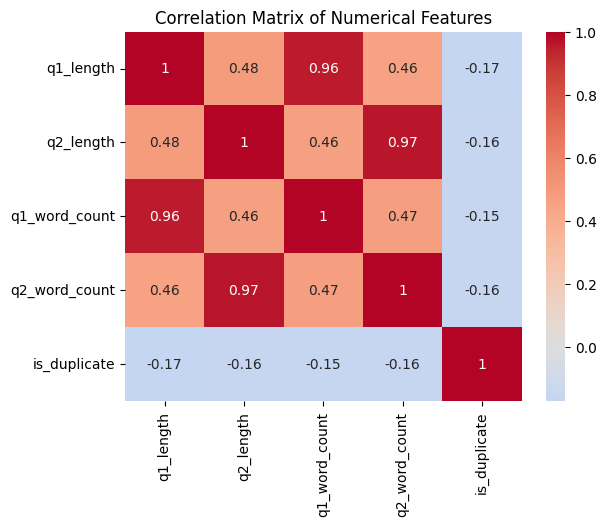

In [ ]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

All correlations with the label are very low. So according to the insights length-based features are NOT meaningful predictors of duplicate questions.

In [6]:
# Basic feature engineering

df1 = train_df.copy()

# Frequency of question 1 and 2
df1['q1_freq'] = df.groupby('qid1')['qid1'].transform('count')
df1['q2_freq'] = df.groupby('qid2')['qid2'].transform('count')

In [7]:
def word_Common(row):

    """The code creates a set w1 of normalized words from the first question in each row of a dataframe, df1.
    The normalization is performed by first splitting the string of the question into a list of words using the delimiter " ", and then applying a lambda function to each word in the list.
    The lambda function converts each word to lowercase using the lower() method, and removes leading and trailing white space using the strip() method.
    The map() function is used to apply this lambda function to each word in the list.
    Finally, the set() function is used to create a set of unique normalized words from the resulting list of words."""


    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return 1.0 * len(w1 & w2) # performs set intersection which  returns set of commons words

In [8]:
df1['words_Common'] = df1.apply(word_Common, axis=1)

In [9]:
def word_share(row):
        w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
        w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
        return 1.0 * len(w1 & w2)/(len(w1) + len(w2))

In [10]:
df1['word_share'] = df1.apply(word_share, axis=1)

In [ ]:
# Correlation analysis
numeric_features = ['q1_length', 'q2_length', 'q1_word_count', 'q2_word_count', 'q1_freq', 'q2_freq', 'words_Common', 'word_share']
correlation_matrix = df1[numeric_features + ['is_duplicate']].corr()

In [ ]:
df1.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_word_count,q2_word_count,q1_freq,q2_freq,words_Common,word_share
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,1,1,10.0,0.434783
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,1,1,4.0,0.200000
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,1,1,4.0,0.166667
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,1,1,0.0,0.000000
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,1,1,2.0,0.100000


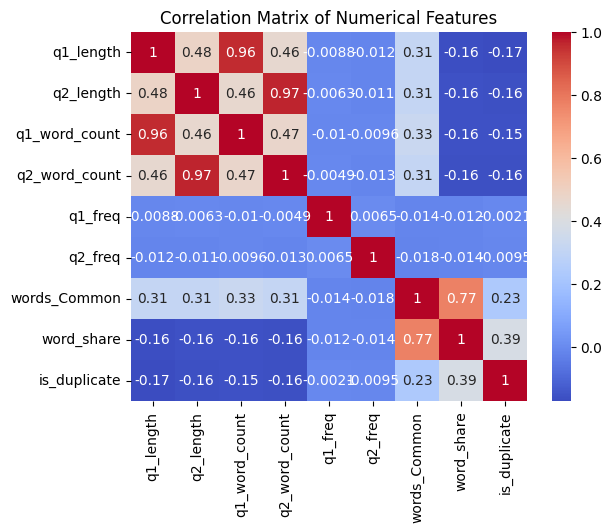

In [ ]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Now correlations are improved than before but still needs improvement.

In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')


def process_text(text):
        """Clean and preprocess text"""

        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))

        # Convert to lowercase
        text = text.lower()

        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()


        tokens = word_tokenize(text)

        # Remove stopwords and normalize
        tokens = [lemmatizer.lemmatize(token) for token in tokens
                     if token not in stop_words and len(token) > 2]

        return ' '.join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [12]:
df_processed = df1.copy()

df_processed["q1_processed"] = df1["question1"].apply(process_text)
df_processed["q2_processed"] = df1["question2"].apply(process_text)

In [ ]:
# Save the DataFrame to a CSV file
df_processed.to_csv('df_processed.csv', index=False)

In [13]:
df_processed = df_processed.drop(columns=['id','qid1','qid2','question1','question2'])

In [14]:
df_processed.head()

,is_duplicate,q1_length,q2_length,q1_word_count,q2_word_count,q1_freq,q2_freq,words_Common,word_share,q1_processed,q2_processed
0,0,66,57,14,12,1,1,10.0,0.434783,step step guide invest share market india,step step guide invest share market
1,0,51,88,8,13,1,1,4.0,0.200000,story kohinoor kohinoor diamond,would happen indian government stole kohinoor ...
2,0,73,59,14,10,1,1,4.0,0.166667,increase speed internet connection using vpn,internet speed increased hacking dns
3,0,50,65,11,9,1,1,0.0,0.000000,mentally lonely solve,find remainder mathmath divided
4,0,76,39,13,7,1,1,2.0,0.100000,one dissolve water quikly sugar salt methane c...,fish would survive salt water


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    df_processed,
    df_processed['is_duplicate'],
    test_size=0.2,
    random_state=42,
    stratify=df_processed['is_duplicate'] # Stratify helps preserve the 63/37 imbalance ratio
)

# Extract question columns for cleaner access
Q1_train = X_train['q1_processed']
Q2_train = X_train['q2_processed']
Q1_test = X_val['q1_processed']
Q2_test = X_val['q2_processed']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

def extract_tfidf_features(Q1_train, Q2_train, Q1_test, Q2_test, max_features=5000):
    """
    Fits TF-IDF only on the combined training corpus and transforms all four sets.
    """
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2))

    # 1. FIT: Learn vocabulary and IDF weights ONLY on the combined TRAINING data
    tfidf.fit(list(Q1_train) + list(Q2_train))

    # 2. TRANSFORM: Apply the learned model to all four sets
    Q1_train_tfidf = tfidf.transform(Q1_train)
    Q2_train_tfidf = tfidf.transform(Q2_train)

    Q1_test_tfidf = tfidf.transform(Q1_test)
    Q2_test_tfidf = tfidf.transform(Q2_test)

    # 3. CONCATENATE Features for Training and Testing sets separately
    X_train_tfidf = hstack([Q1_train_tfidf, Q2_train_tfidf])
    X_test_tfidf = hstack([Q1_test_tfidf, Q2_test_tfidf])

    return X_train_tfidf, X_test_tfidf

In [ ]:
# 1. Get TF-IDF matrices
X_train_tfidf, X_test_tfidf = extract_tfidf_features(
    Q1_train, Q2_train, Q1_test, Q2_test, max_features=5000
)

# 2. Extract numeric features from the corresponding dataframes
X_train_numeric = X_train[numeric_features].values
X_test_numeric = X_val[numeric_features].values

# 3. Final Horizontal Stacking
# Combine the TF-IDF features and numeric features for the training set
X_train_final = hstack([X_train_tfidf, X_train_numeric])

# Combine the TF-IDF features and numeric features for the testing set
X_test_final = hstack([X_test_tfidf, X_test_numeric])

DID NOT CONVERT TO .toarray(). Dense matrix memory was causing immidiate notebook crash.
Now the entire point of TF-IDF is that it is sparse.

Neural networks cannot use sparse matrices easily,
but Logistic Regression / SVM / Random Forest can.

In [ ]:
print(X_train_final.shape)

(323478, 10008)


Quick baseline check (SVM and Random Forest) on current features.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

svm = LinearSVC()
svm.fit(X_train_final, y_train)


pred = svm.predict(X_test_final)

print("Accuracy:", accuracy_score(y_val, pred))
print("F1 Score:", f1_score(y_val, pred))
print(classification_report(y_val, pred))


Accuracy: 0.7838877210337579
F1 Score: 0.6948687955025578
              precision    recall  f1-score   support

           0       0.81      0.85      0.83     51009
           1       0.73      0.67      0.69     29861

    accuracy                           0.78     80870
   macro avg       0.77      0.76      0.76     80870
weighted avg       0.78      0.78      0.78     80870



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_final,y_train)

pred = rf.predict(X_test_final)

print("Accuracy:", accuracy_score(y_val, pred))
print("F1 Score:", f1_score(y_val, pred))
print(classification_report(y_val, pred))

Accuracy: 0.8191789291455422
F1 Score: 0.7439547547757875
              precision    recall  f1-score   support

           0       0.84      0.88      0.86     51009
           1       0.78      0.71      0.74     29861

    accuracy                           0.82     80870
   macro avg       0.81      0.80      0.80     80870
weighted avg       0.82      0.82      0.82     80870



Models tend to bias toward class 0 because of the mild imbalance.

Also got decent results. The current features are giving some basic term overlap and structural information. However, the models are missing the deep semantic meaning and context between the question pairs.

So adding more advanced features like Token Overlap Features & Fuzzy Features for capturing deep semantic meaning and context of the questions with help improve even further.

In [15]:
# Further feature engineering
from nltk.corpus import stopwords
from typing import List, Dict, Any

def fetch_token_features(row):
    """
    Calculates 8 lexical overlap features between two questions in a row dictionary.

    Args:
        row: A dictionary with keys 'question1' and 'question2'.

    Returns:
        A list of 8 float features representing token similarity metrics.
    """

    q1 = row.get('question1', '')
    q2 = row.get('question2', '')

    SAFE_DIV = 0.0001
    STOP_WORDS = set(stopwords.words("english"))

    # 1. Tokenize and Handle Empty Questions
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    # Return 8 zeros if either question is empty
    if not q1_tokens or not q2_tokens:
        return [0.0] * 8

    # 2. Separate Words and Stop Words using Sets for efficiency
    q1_words = {word for word in q1_tokens if word not in STOP_WORDS}
    q2_words = {word for word in q2_tokens if word not in STOP_WORDS}

    q1_stops = {word for word in q1_tokens if word in STOP_WORDS}
    q2_stops = {word for word in q2_tokens if word in STOP_WORDS}

    q1_tokens_set = set(q1_tokens)
    q2_tokens_set = set(q2_tokens)

    # 3. Calculate Overlap Counts
    common_word_count = len(q1_words.intersection(q2_words))
    common_stop_count = len(q1_stops.intersection(q2_stops))
    common_token_count = len(q1_tokens_set.intersection(q2_tokens_set))

    # 4. Calculate Lengths for Ratios
    q1_len_words = len(q1_words)
    q2_len_words = len(q2_words)
    q1_len_stops = len(q1_stops)
    q2_len_stops = len(q2_stops)
    q1_len_tokens = len(q1_tokens)
    q2_len_tokens = len(q2_tokens)

    # 5. Compile Features
    token_features = [
        # Common Non-Stop Words Ratios
        common_word_count / (min(q1_len_words, q2_len_words) + SAFE_DIV), # [0]
        common_word_count / (max(q1_len_words, q2_len_words) + SAFE_DIV), # [1]

        # Common Stop Words Ratios
        common_stop_count / (min(q1_len_stops, q2_len_stops) + SAFE_DIV), # [2]
        common_stop_count / (max(q1_len_stops, q2_len_stops) + SAFE_DIV), # [3]

        # Common All Token Ratios
        common_token_count / (min(q1_len_tokens, q2_len_tokens) + SAFE_DIV), # [4]
        common_token_count / (max(q1_len_tokens, q2_len_tokens) + SAFE_DIV), # [5]

        # Positional Matches
        float(q1_tokens[-1] == q2_tokens[-1]),                           # [6] Last word match
        float(q1_tokens[0] == q2_tokens[0])                             # [7] First word match
    ]

    return token_features

In [16]:
df_processed_new = df1.copy()
token_features = df_processed_new.apply(fetch_token_features, axis=1)

In [17]:
df_processed_new["cwc_min"]       = list(map(lambda x: x[0], token_features))
df_processed_new["cwc_max"]       = list(map(lambda x: x[1], token_features))
df_processed_new["csc_min"]       = list(map(lambda x: x[2], token_features))
df_processed_new["csc_max"]       = list(map(lambda x: x[3], token_features))
df_processed_new["ctc_min"]       = list(map(lambda x: x[4], token_features))
df_processed_new["ctc_max"]       = list(map(lambda x: x[5], token_features))
df_processed_new["last_word_eq"]  = list(map(lambda x: x[6], token_features))
df_processed_new["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [18]:
!pip install fuzzywuzzy python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.8 MB/s eta 0:00:00


In [19]:
from fuzzywuzzy import fuzz
from typing import Dict, List

def fetch_fuzzy_features(row):
    """
    Calculates 4 string similarity features using fuzzywuzzy between two questions.

    Args:
        row: A dictionary containing the question strings with keys
             'question1' and 'question2'.

    Returns:
        A list of 4 float features (Quick Ratio, Partial Ratio,
        Token Sort Ratio, and Token Set Ratio).
    """

    # Safely retrieve questions, defaulting to empty string if key is missing
    q1 = row.get('question1', '')
    q2 = row.get('question2', '')

    # If either question is empty, return 4 zeros
    if not q1 or not q2:
        return [0.0] * 4

    # Calculate the four standard fuzzy features
    fuzzy_features = [
        # [0] Quick Ratio (Standard Levenshtein distance-based comparison)
        float(fuzz.QRatio(q1, q2)),

        # [1] Partial Ratio (Finds the best match among substrings)
        float(fuzz.partial_ratio(q1, q2)),

        # [2] Token Sort Ratio (Compares strings after sorting their words/tokens)
        float(fuzz.token_sort_ratio(q1, q2)),

        # [3] Token Set Ratio (Compares sets of tokens, ignoring order and duplicates)
        float(fuzz.token_set_ratio(q1, q2))
    ]

    return fuzzy_features

In [20]:
fuzzy_features = df_processed_new.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
df_processed_new['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
df_processed_new['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
df_processed_new['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
df_processed_new['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [21]:
df_processed_new.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_word_count,q2_word_count,...,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,...,0.999980,0.999980,0.833326,0.714281,0.0,1.0,93.0,98.0,93.0,100.0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,...,0.499975,0.333322,0.499994,0.307690,0.0,1.0,66.0,73.0,63.0,86.0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,...,0.249994,0.166664,0.299997,0.214284,0.0,1.0,54.0,53.0,66.0,66.0


In [22]:
df_processed_new["q1_processed"] = df_processed_new["question1"].apply(process_text)
df_processed_new["q2_processed"] = df_processed_new["question2"].apply(process_text)

In [ ]:
# Save the DataFrame to a CSV file
df_processed_new.to_csv('df_processed_new.csv', index=False)

In [23]:
df_processed_new = df_processed_new.drop(columns=['id','qid1','qid2','question1','question2'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    df_processed_new,
    df_processed['is_duplicate'],
    test_size=0.2,
    random_state=42,
    stratify=df_processed['is_duplicate'] # Stratify helps preserve the 63/37 imbalance ratio
)

# Extract question columns for cleaner access
Q1_train = X_train['q1_processed']
Q2_train = X_train['q2_processed']
Q1_test = X_val['q1_processed']
Q2_test = X_val['q2_processed']

In [ ]:
numeric_features = df_processed_new.select_dtypes(include=['number']).columns.tolist()

In [ ]:
# 1. Get TF-IDF matrices
X_train_tfidf, X_val_tfidf = extract_tfidf_features(
    Q1_train, Q2_train, Q1_test, Q2_test, max_features=5000
)

# 2. Extract numeric features from the corresponding dataframes
X_train_numeric = X_train[numeric_features].values
X_val_numeric = X_val[numeric_features].values

# 3. Final Horizontal Stacking
# Combine the TF-IDF features and numeric features for the training set
X_train_final = hstack([X_train_tfidf, X_train_numeric])

# Combine the TF-IDF features and numeric features for the testing set
X_val_final = hstack([X_val_tfidf, X_val_numeric])

TF-IDF Baselinecheck (SVM and Random Forest) on final features

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

svm = LinearSVC()
svm.fit(X_train_final, y_train)


pred = svm.predict(X_val_final)

print("Accuracy:", accuracy_score(y_val, pred))
print("F1 Score:", f1_score(y_val, pred))
print(classification_report(y_val, pred))

Accuracy: 0.7994930134784222
F1 Score: 0.7200593891890958
              precision    recall  f1-score   support

           0       0.83      0.86      0.84     51009
           1       0.74      0.70      0.72     29861

    accuracy                           0.80     80870
   macro avg       0.79      0.78      0.78     80870
weighted avg       0.80      0.80      0.80     80870



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_final,y_train)

pred = rf.predict(X_val_final)

print("Accuracy:", accuracy_score(y_val, pred))
print("F1 Score:", f1_score(y_val, pred))
print(classification_report(y_val, pred))

Accuracy: 0.8259181402250525
F1 Score: 0.7614060063724494
              precision    recall  f1-score   support

           0       0.86      0.87      0.86     51009
           1       0.77      0.75      0.76     29861

    accuracy                           0.83     80870
   macro avg       0.81      0.81      0.81     80870
weighted avg       0.83      0.83      0.83     80870



After adding advanced features like Token Overlap Features & Fuzzy Features, found good improved benchmark form baseline models(SVM and Random Forest) with TF-IDF.